In [ ]:
import os
import numpy as np
import pandas as pd


def build_castings(csv_path="casting_inspection.csv", seed=190, verbose=False):
    """Aluminium casting inspection records for a DATA-CENTRIC AI lab (U19).

    Each casting has objective process/measurement features and a true (latent) defect
    state. Three human inspectors each label it — but humans are noisy and disagree, more
    so on borderline parts. The column you'd actually TRAIN on (`label_recorded`) is a
    single inspector's call and therefore contains real labelling errors.

    Columns:
      porosity_pct, wall_thickness_mm, fill_time_s, melt_temp_c, pressure_bar, surface_ra_um
                                          -> objective features
      inspector_A / inspector_B / inspector_C  -> three human labels (0 ok / 1 defect)
       label_recorded                      -> the noisy single-annotator label (train on this)
      true_defect                         -> hidden ground truth (for teaching/validation only)
    """
    rng = np.random.default_rng(seed)
    N = 2400

    porosity = rng.gamma(2.0, 1.1, N).clip(0, 12)
    wall = rng.normal(6.0, 0.8, N).clip(3.5, 8.5)
    fill_time = rng.normal(2.4, 0.5, N).clip(1.0, 4.5)
    melt_temp = rng.normal(710, 15, N).clip(660, 760)
    pressure = rng.normal(95, 12, N).clip(60, 130)
    surface_ra = rng.normal(3.2, 0.9, N).clip(1.0, 7.0)

    # true defect: a SHARP function of genuine drivers so it is learnable from features
    # (steep sigmoid -> probabilities pushed toward 0/1 -> high but not perfect ceiling)
    drive = (0.55 * porosity + 1.3 * np.maximum(4.8 - wall, 0)
      + 1.1 * np.maximum(fill_time - 2.9, 0) + 0.45 * np.maximum(surface_ra - 3.6, 0)
             + 0.04 * np.maximum(melt_temp - 720, 0))
    thr = np.quantile(drive, 0.80)            # ~20% defect rate
    p_true = 1 / (1 + np.exp(-2.2 * (drive - thr)))   # gain 2.2 -> sharp, ~10% label noise
    true_defect = (rng.random(N) < p_true).astype(int)

    # "difficulty": borderline parts (p near 0.5) are where inspectors disagree
    difficulty = 1 - np.abs(p_true - 0.5) * 2          # 0 easy .. 1 hard
    def inspector(skill):
        # flip the true label with prob rising on hard parts, lower for higher skill
        flip_p = (0.07 + 0.55 * difficulty) * (1.0 - skill)
        flips = rng.random(N) < flip_p
        return np.where(flips, 1 - true_defect, true_defect)

    insp_A = inspector(0.80)
    insp_B = inspector(0.66)
    insp_C = inspector(0.52)          # least reliable inspector
    label_recorded = true_defect.copy()
    ra_hi = np.quantile(surface_ra, 0.60); ra_lo = np.quantile(surface_ra, 0.40)
    rough_ok = (true_defect == 0) & (surface_ra > ra_hi)
    label_recorded[rough_ok & (rng.random(N) < 0.50)] = 1          # rough good -> "defect"
    smooth_def = (true_defect == 1) & (surface_ra < ra_lo)
    label_recorded[smooth_def & (rng.random(N) < 0.50)] = 0        # smooth defect -> missed
    rand_flip = rng.random(N) < 0.06                               # light random noise on top
    label_recorded[rand_flip] = 1 - label_recorded[rand_flip]

    df = pd.DataFrame({
        "porosity_pct": porosity.round(2), "wall_thickness_mm": wall.round(2),
        "fill_time_s": fill_time.round(2), "melt_temp_c": melt_temp.round(1),
        "pressure_bar": pressure.round(1), "surface_ra_um": surface_ra.round(2),
        "inspector_A": insp_A, "inspector_B": insp_B, "inspector_C": insp_C,
        "label_recorded": label_recorded, "true_defect": true_defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from itertools import combinations
        print("castings:", df.shape)
        print("true defect rate:", round(true_defect.mean(), 3))
        print("recorded-label error rate vs truth:", round((df.label_recorded != df.true_defect).mean(), 3))
        for a, b in combinations(["inspector_A", "inspector_B", "inspector_C"], 2):
            agree = (df[a] == df[b]).mean()
            print(f"  raw agreement {a[-1]}-{b[-1]}: {agree:.3f}")
        cons = (df[["inspector_A", "inspector_B", "inspector_C"]].sum(axis=1) >= 2).astype(int)
        print("  consensus(majority) error rate:", round((cons != df.true_defect).mean(), 3))
    return df

if not os.path.exists('casting_inspection.csv'):
    build_castings(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')


import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('casting_inspection.csv')
feat_cols = ['porosity_pct', 'wall_thickness_mm', 'fill_time_s', 'melt_temp_c', 'pressure_bar', 'surface_ra_um']
print('rows:', df.shape)
print('recorded-label defect rate:', round(df.label_recorded.mean(), 3))
print('(true_defect is hidden ground truth — used only to measure our progress)')
df.head(3)

Generated dataset file.
rows: (2400, 11)
recorded-label defect rate: 0.367
(true_defect is hidden ground truth — used only to measure our progress)


,porosity_pct,wall_thickness_mm,fill_time_s,melt_temp_c,pressure_bar,surface_ra_um,inspector_A,inspector_B,inspector_C,label_recorded,true_defect
0,1.28,5.11,2.73,710.8,103.7,2.08,0,0,1,0,0
1,1.14,5.47,2.37,706.4,85.7,2.84,1,0,0,1,0
2,0.58,6.69,2.16,709.9,92.9,3.90,0,0,0,0,0


In [ ]:
# -----------------------------------------------------------
# 🔹 1A. COHEN'S KAPPA BETWEEN EACH PAIR OF INSPECTORS
# -----------------------------------------------------------
from sklearn.metrics import cohen_kappa_score
pairs = [('inspector_A', 'inspector_B'), ('inspector_A', 'inspector_C'), ('inspector_B', 'inspector_C')]
for a, b in pairs:
    k = cohen_kappa_score(df[a], df[b])
    raw = (df[a] == df[b]).mean()
    print(f'{a[-1]}-{b[-1]}: raw agreement {raw:.3f} | Cohen kappa {k:.3f}')
print('\nKappa corrects raw agreement for chance. <0.4 weak, 0.4-0.6 moderate, 0.6-0.8 substantial.')


A-B: raw agreement 0.887 | Cohen kappa 0.723
A-C: raw agreement 0.855 | Cohen kappa 0.648
B-C: raw agreement 0.837 | Cohen kappa 0.608

Kappa corrects raw agreement for chance. <0.4 weak, 0.4-0.6 moderate, 0.6-0.8 substantial.


In [ ]:
# 1. Kappa of each inspector vs true_defect

inspectors = ["inspector_A", "inspector_B", "inspector_C"]  # adjust names if needed

for inspector in inspectors:
    kappa = cohen_kappa_score(df[inspector], df["true_defect"])
    print(f"{inspector}: Cohen's Kappa = {kappa:.3f}")

inspector_A: Cohen's Kappa = 0.886
inspector_B: Cohen's Kappa = 0.806
inspector_C: Cohen's Kappa = 0.725


In [ ]:
# -----------------------------------------------------------
# 🔹 2A. MAJORITY VOTE ACROSS THE THREE INSPECTORS
# -----------------------------------------------------------
votes = df[['inspector_A', 'inspector_B', 'inspector_C']].sum(axis=1)
df['label_consensus'] = (votes >= 2).astype(int)   # >=2 of 3 say defect
acc_single = (df['label_recorded'] == df['true_defect']).mean()
acc_consensus = (df['label_consensus'] == df['true_defect']).mean()
print(f'single recorded label accuracy vs truth: {acc_single:.3f}')
print(f'majority-vote consensus accuracy vs truth: {acc_consensus:.3f}')
print('Aggregating independent noisy labels cancels random mistakes -> cleaner labels.')


single recorded label accuracy vs truth: 0.777
majority-vote consensus accuracy vs truth: 0.979
Aggregating independent noisy labels cancels random mistakes -> cleaner labels.


In [ ]:
# -----------------------------------------------------------
# 🔹 3A. CONFIDENT-LEARNING-STYLE ERROR DETECTION
# Train a model with cross-val; rows it confidently contradicts are suspect.
# -----------------------------------------------------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
X = df[feat_cols].values
y_noisy = df['label_recorded'].values
clf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=300, random_state=0))
proba = cross_val_predict(clf, X, y_noisy, cv=5, method='predict_proba')[:, 1]
# suspect = model is confident the label is the OTHER class
suspect = ((proba > 0.80) & (y_noisy == 0)) | ((proba < 0.20) & (y_noisy == 1))
really_wrong = (df['label_recorded'] != df['true_defect']).values
base_rate = really_wrong.mean()
precision = (suspect & really_wrong).sum() / max(suspect.sum(), 1)
print(f'flagged {int(suspect.sum())} rows as suspect.')
print(f'of the flagged rows, {precision:.1%} really were wrong  (vs {base_rate:.1%} base error rate).')
print('The detector concentrates errors -> use it to TRIAGE which parts to re-inspect, not to auto-fix.')


flagged 107 rows as suspect.
of the flagged rows, 48.6% really were wrong  (vs 22.3% base error rate).
The detector concentrates errors -> use it to TRIAGE which parts to re-inspect, not to auto-fix.


In [ ]:
# True labeling errors
true_errors = (df["label_recorded"] != df["true_defect"])

# Number of flagged samples
n_flagged = suspect.sum()

# Base error rate
base_rate = true_errors.mean()

# Real errors in the flagged set
real_errors_found = (true_errors & suspect).sum()

# Expected errors if the same number of rows were picked at random
expected_random = n_flagged * base_rate

print("Real errors found:", real_errors_found)
print("Expected by random selection:", expected_random)


Real errors found: 52
Expected by random selection: 23.852083333333336


In [ ]:
# -----------------------------------------------------------
# 🔹 4A. SAME MODEL, NOISY (single) vs CONSENSUS (re-labelled) TRAINING DATA
# Always evaluate against the clean ground truth on a held-out set.
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
idx = np.arange(len(df))
tr, te = train_test_split(idx, test_size=0.3, random_state=42, stratify=df['true_defect'])
def train_eval(train_labels, model=None):
    if model is None:
        model = RandomForestClassifier(n_estimators=300, random_state=0)
    m = make_pipeline(StandardScaler(), model)
    m.fit(X[tr], train_labels[tr])
    return f1_score(df['true_defect'].values[te], m.predict(X[te])), m # Return f1 score AND the fitted pipeline
f1_noisy, _ = train_eval(df['label_recorded'].values) # Unpack only f1_noisy
f1_consensus, _ = train_eval(df['label_consensus'].values) # Unpack only f1_consensus
print(f'F1 (trained on NOISY single labels):     {f1_noisy:.3f}')
print(f'F1 (trained on CONSENSUS re-labelled):   {f1_consensus:.3f}')
print(f'data-centric gain from better labels:    {f1_consensus - f1_noisy:+.3f}')
print('Same model, same features — only the labels improved.')

F1 (trained on NOISY single labels):     0.504
F1 (trained on CONSENSUS re-labelled):   0.667
data-centric gain from better labels:    +0.162
Same model, same features — only the labels improved.


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

# 1. Try stronger models while keeping the noisy 'label_recorded'

gb_model = GradientBoostingClassifier(random_state=42)
rf_deep = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42
)

print("Gradient Boosting (trained on label_recorded):")
f1_gb, gb_pipeline = train_eval(df["label_recorded"], model=gb_model)

print("\nDeeper Random Forest (trained on label_recorded):")
f1_rf, rf_pipeline = train_eval(df["label_recorded"], model=rf_deep)

print("\nConsensus-trained model:")
f1_consensus, _ = train_eval(df["label_consensus"])

print(f"\nGradient Boosting F1: {f1_gb:.3f}")
print(f"Deep Random Forest F1: {f1_rf:.3f}")
print(f"Consensus-trained F1: {f1_consensus:.3f}")


Gradient Boosting (trained on label_recorded):

Deeper Random Forest (trained on label_recorded):

Consensus-trained model:

Gradient Boosting F1: 0.510
Deep Random Forest F1: 0.499
Consensus-trained F1: 0.667


Feature Importances for Random Forest (trained on label_recorded):


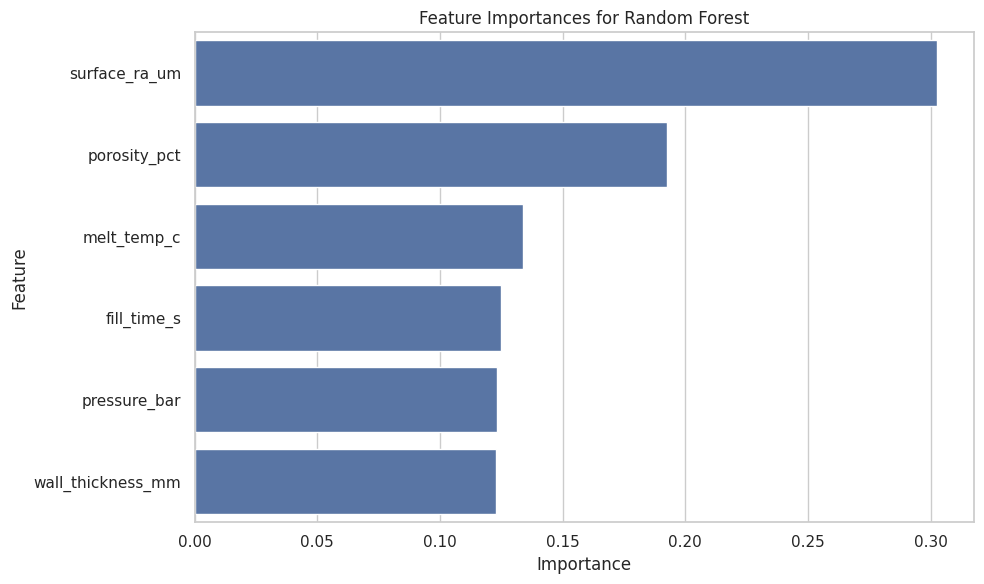


Feature Importances for Gradient Boosting (trained on label_recorded):


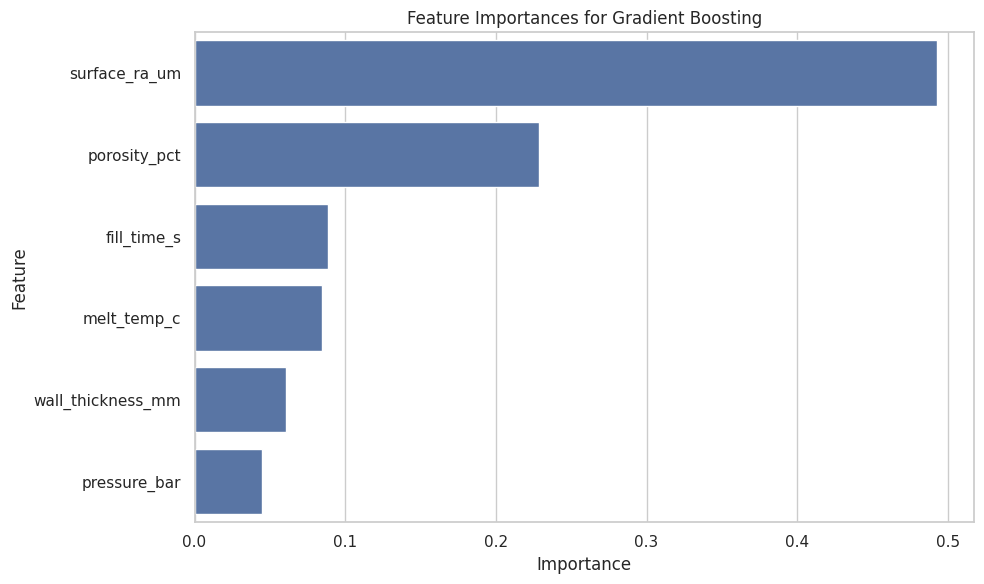

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. COMPARE FEATURE IMPORTANCE
# -----------------------------------------------------------

def plot_feature_importances(model_pipeline, model_name, feature_names):
    # The last step in the pipeline is the actual model
    model = model_pipeline.named_steps[model_pipeline.steps[-1][0]]
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
        feature_importance_df = pd.DataFrame({
            'Feature': feature_names,
            'Importance': importances
        }).sort_values(by='Importance', ascending=False)

        plt.figure(figsize=(10, 6))
        sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
        plt.title(f'Feature Importances for {model_name}')
        plt.xlabel('Importance')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"Model {model_name} does not have feature_importances_ attribute.")

print("Feature Importances for Random Forest (trained on label_recorded):")
plot_feature_importances(rf_pipeline, "Random Forest", feat_cols)

print("\nFeature Importances for Gradient Boosting (trained on label_recorded):")
plot_feature_importances(gb_pipeline, "Gradient Boosting", feat_cols)

In [ ]:
# -----------------------------------------------------------
# 🔹 5A. ACTIVE LEARNING — LABEL THE MOST UNCERTAIN PARTS NEXT
# -----------------------------------------------------------
# Simulate a small labelled budget: which unlabelled parts should we send to inspection?
rng = np.random.default_rng(0)
labelled = rng.choice(idx, 150, replace=False)
pool = np.setdiff1d(idx, labelled)
m = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=0))
m.fit(X[labelled], df['true_defect'].values[labelled])
pool_proba = m.predict_proba(X[pool])[:, 1]
uncertainty = 1 - np.abs(pool_proba - 0.5) * 2     # 1 = most uncertain (proba near 0.5)
next_to_label = pool[np.argsort(-uncertainty)[:20]]
print('20 most informative parts to label next (indices):')
print(next_to_label[:20])
print('Active learning spends the labelling budget where the model is least sure.')

# 🧪 EXERCISE 5 — Weak supervision: rules as labels

20 most informative parts to label next (indices):
[1027  737 1721 1760 2131 1723 1862  960  626 1276  891   84 1998  435
 1333  398  855 1535  196 1551]
Active learning spends the labelling budget where the model is least sure.


In [ ]:
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Write labelling functions (heuristics)

def lf_porosity(row):
    return 1 if row["porosity_pct"] > 6 else 0

def lf_thickness(row):
    return 1 if row["wall_thickness_mm"] < 4.5 else 0

def lf_surface(row):
    return 1 if row["surface_ra_um"] > 5 else 0

# Apply the rules
rule1 = df.apply(lf_porosity, axis=1)
rule2 = df.apply(lf_thickness, axis=1)
rule3 = df.apply(lf_surface, axis=1)

# 2. Combine rules using majority voting
weak_label = (
    (rule1 + rule2 + rule3) >= 2
).astype(int)

# Compare with ground truth
weak_acc = accuracy_score(df["true_defect"], weak_label)

# Compare with a single inspector (adjust column name if needed)
inspector_acc = accuracy_score(df["true_defect"], df["label_recorded"])

print(f"Weak-label Accuracy: {weak_acc:.3f}")
print(f"Single Inspector Accuracy: {inspector_acc:.3f}")


Weak-label Accuracy: 0.741
Single Inspector Accuracy: 0.777
